In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras

# Setting random seeds to get reproducible results
np.random.seed(0)
import tensorflow as tf
tf.random.set_seed(1)

In [2]:
# Import data

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print("Size of the training set", len(x_train))
print("Size of the testing set", len(x_test))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 12s 1us/step
Size of the training set 60000
Size of the testing set 10000


The label is 1


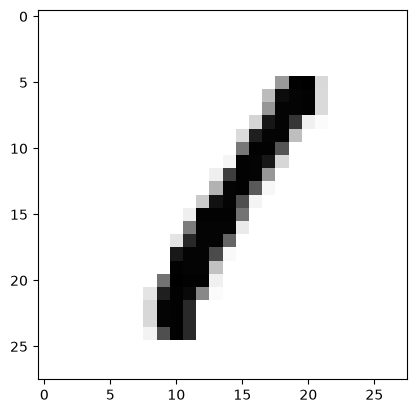

In [6]:
plt.imshow(x_train[3], cmap='Greys')
print("The label is", y_train[3])

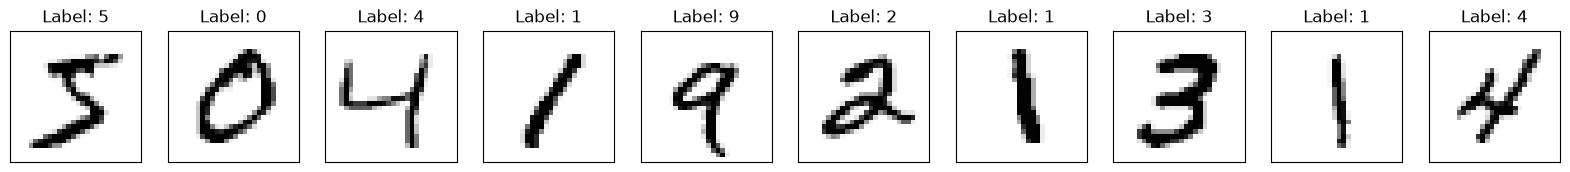

In [7]:
fig = plt.figure(figsize=(20, 20))
for i in range(10):
    ax = fig.add_subplot(1, 10, i + 1, xticks=[], yticks=[])
    ax.imshow(x_train[i], cmap='Greys')
    ax.set_title("Label: {}".format(y_train[i]))

# Pre-processing the data


In [8]:
# Reshaping the features.
# In the reshape function we use the -1 as a placeholder for the size of the dataset.

x_train_reshaped = x_train.reshape(-1, 28*28)
x_test_reshaped = x_test.reshape(-1, 28*28)

In [9]:
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

# Building the model
model = Sequential([
    Input(shape=(28 * 28,)),

    Dense(128, activation="relu"),
    Dropout(0.2),

    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(10, activation="softmax")
])

# Compiling the model
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.fit(x_train_reshaped, y_train_cat, epochs=10, batch_size=10)

Epoch 1/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.4943 - loss: 2.0569
Epoch 2/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7270 - loss: 0.8780
Epoch 3/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.8249 - loss: 0.6224
Epoch 4/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.8668 - loss: 0.4964
Epoch 5/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.8835 - loss: 0.4517
Epoch 6/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.8969 - loss: 0.3951
Epoch 7/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9039 - loss: 0.3843
Epoch 8/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9093 - loss: 0.3720
Epoch 9/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.9131 - loss: 0.3634
Epoch 10/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.9175 - loss: 0.3411


In [12]:
predictions_vector = model.predict(x_test_reshaped)
predictions = [np.argmax(pred) for pred in predictions_vector]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 713us/step


The label is 4
The prediction is 4


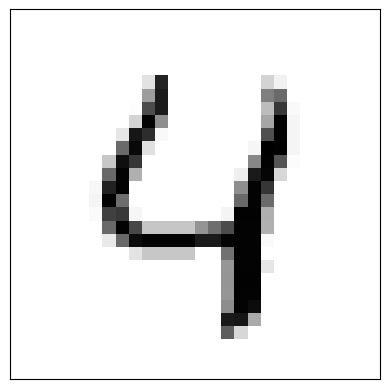

In [13]:
plt.imshow(x_test[4], cmap='Greys')
plt.xticks([])
plt.yticks([])
print("The label is", y_test[4])
print("The prediction is", predictions[4])

The label is 3
The prediction is 3


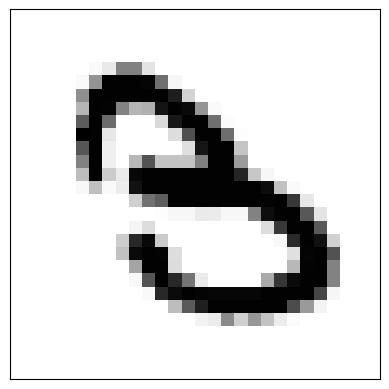

In [14]:
plt.imshow(x_test[18], cmap='Greys')
plt.xticks([])
plt.yticks([])
print("The label is", y_test[18])
print("The prediction is", predictions[18])

In [15]:
num_correct = 0
for i in range(len(predictions)):
    if predictions[i] == y_test[i]:
        num_correct += 1

print("The model is correct", num_correct, "times out of", len(y_test))
print("The accuracy is", num_correct/len(y_test))

The model is correct 9502 times out of 10000
The accuracy is 0.9502
